# Machine Learning : Prédiction de la Classification des Jeux

## Objectif
L'objectif de ce notebook est d'utiliser des techniques de Machine Learning pour prédire le **Genre principal** d'un jeu à partir de ses autres attributs (Mécaniques, Thèmes, Esthétique, etc.). 

Nous allons comparer plusieurs modèles, dont **Random Forest** et **XGBoost**, ainsi qu'un modèle d'ensemble, en analysant l'ensemble des genres Steam, pas seulement les genres RPG.

## Définitions Ludologiques Clés (selon la littérature académique)

### Termes Fondamentaux
- **Gameplay** : L'ensemble des mécaniques, des règles et des interactions qui constituent l'expérience interactive du joueur (Swink, 2009 ; Schell, 2019).
- **Genre** : Classification thématique ou ludique d'un jeu (ex: Action, RPG, Puzzle) basée sur des conventions narratives ou mécaniques récurrentes.
- **Mechanics** (Mécaniques) : Les règles, systèmes et interactions que le joueur contrôle directement pour progresser dans le jeu (Schell, 2019).
- **Theme** (Thème) : Le contexte narratif ou contextuel du jeu (ex: science-fiction, fantasy, histoire).
- **Setting** (Univers) : Le cadre spatial et temporel dans lequel se déroule le jeu.
- **Mood** (Ambiance) : L'atmosphère émotionnelle transmise par le jeu (ex: horrifique, épique, apaisant).
- **Aesthetics** (Esthétique) : Les éléments visuels, sonores et sensoriels qui composent l'expérience du joueur.
- **Perspective** : Le point de vue d'où le joueur observe et agit dans le monde du jeu (1ère personne, 3ème personne, isométrique, etc.).
- **Players** (Nombre de joueurs) : Dimension sociale du gameplay (solo, multijoueur coopératif, compétitif).

## Démarche
1. **Fondamentaux Ludologiques** : Définition des termes clés basée sur la littérature académique.
2. **Exploration des données (EDA)** : Analyse de la répartition des genres dans tous les domaines.
3. **Ingénierie des caractéristiques** : Multi-hot encoding des tags.
4. **Sélection de modèles** : Comparaison de Random Forest, XGBoost et Voting Classifier.
5. **Optimisation** : Application de SMOTE et Tuning d'hyperparamètres.
6. **Comparaison Experts vs Folksonomy** : Analyse comparative des genres officiels avec les dimensions folksonômiques.
7. **Comparaison Finale** : Analyse comparative des performances avant et après optimisation.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from imblearn.over_sampling import SMOTE

# Chargement des données
df_train_full = pd.read_csv('../data/New_Games_Gameplay_Taxonomy.csv')
df_test = pd.read_csv('../data/final_test_set_15k.csv')

print(f"Base d'entraînement : {df_train_full.shape}")
print(f"Base de test : {df_test.shape}")

Base d'entraînement : (126244, 10)
Base de test : (15000, 10)


## 1. Analyse Exploratoire des Données (EDA) : Répartition des Genres

Avant de commencer la modélisation, il est crucial de comprendre la distribution de notre variable cible (`Primary_Genre`).

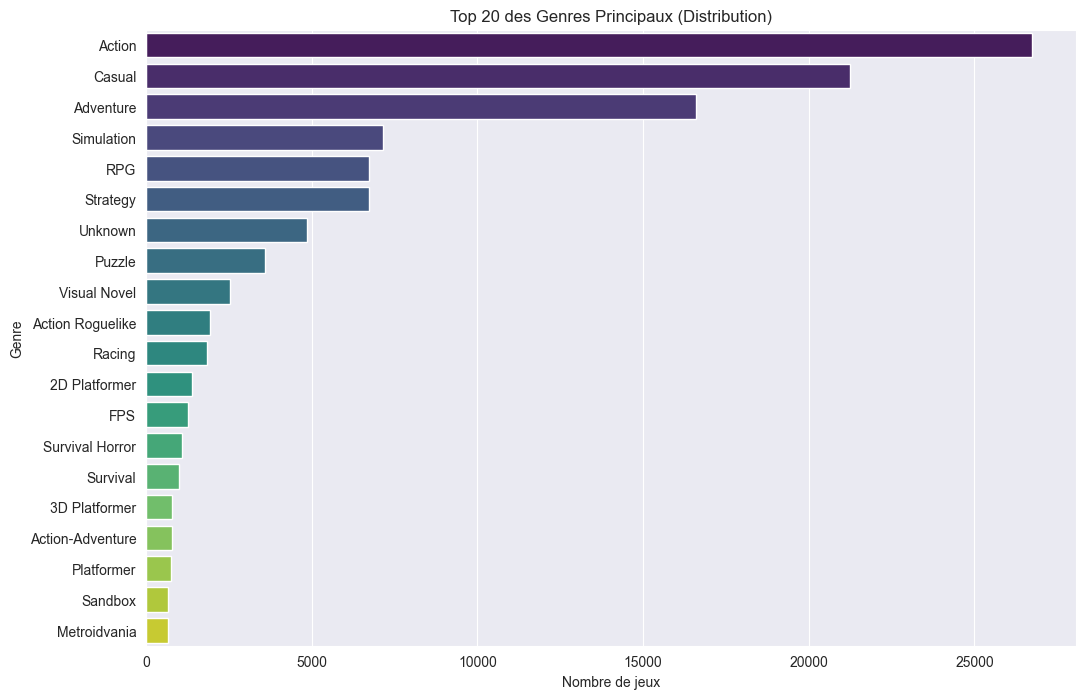

Nombre total de genres uniques : 104
Le genre le plus fréquent (Action) représente 26730 jeux.
Le 20ème genre (Metroidvania) ne représente que 666 jeux.


In [9]:
# Extraction du premier genre listé comme 'Genre Principal'
def get_primary(genre_str):
    if pd.isna(genre_str):
        return 'Unknown'
    return genre_str.split(', ')[0]

df_train_full['Primary_Genre'] = df_train_full['Genre'].apply(get_primary)

# Calcul des comptes
genre_counts = df_train_full['Primary_Genre'].value_counts()
top_20_genres = genre_counts.head(20)

# Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_genres.reset_index().rename(columns={'index': 'Genre', 'Primary_Genre': 'Count'}),
            x='Count', y='Genre', hue='Genre', palette='viridis', legend=False)
plt.title('Top 20 des Genres Principaux (Distribution)')
plt.xlabel('Nombre de jeux')
plt.ylabel('Genre')
plt.show()

print(f"Nombre total de genres uniques : {df_train_full['Primary_Genre'].nunique()}")
print(f"Le genre le plus fréquent ({genre_counts.index[0]}) représente {genre_counts.iloc[0]} jeux.")
print(f"Le 20ème genre ({genre_counts.index[19]}) ne représente que {genre_counts.iloc[19]} jeux.")

**Observation :**
Nous observons un fort **déséquilibre des classes**, très représentative d'**une distribution de Pareto**. Les genres comme "Action", "Casual" et "Adventure" (souvent mal classé comme genre) dominent largement, tandis que des genres spécifiques comme "Sandbox" ou "Metroidvania" sont beaucoup moins représentés.
Cela suggère que :
1. L'accuracy simple ne sera pas une métrique suffisante (un modèle qui prédit toujours "Action" aurait une bonne accuracy).
2. Nous devrons probablement utiliser des techniques de rééquilibrage (comme SMOTE) pour aider le modèle à apprendre les genres minoritaires.

## 2. Préparation des Données et Feature Engineering

In [10]:
# Filtrage : on ne garde que les genres ayant au moins 500 occurrences pour avoir une base statistique suffisante
threshold = 500
valid_genres = df_train_full['Primary_Genre'].value_counts()[df_train_full['Primary_Genre'].value_counts() > threshold].index
df_train = df_train_full[df_train_full['Primary_Genre'].isin(valid_genres) & (df_train_full['Primary_Genre'] != 'Unknown')].copy()

print(f"Nombre de genres conservés après filtrage : {len(valid_genres)}")

dimensions = ['Aesthetics', 'Mechanics', 'Mood', 'Perspective', 'Players', 'Setting', 'Theme']

def prepare_features(df, mlb_dict=None):
    combined_tags = df[dimensions].fillna('').apply(lambda row: [t.strip() for dim in dimensions for t in row[dim].split(',') if t.strip()], axis=1)
    if mlb_dict is None:
        mlb = MultiLabelBinarizer()
        X = mlb.fit_transform(combined_tags)
        return X, mlb
    else:
        X = mlb_dict.transform(combined_tags)
        return X

X_train_full, mlb = prepare_features(df_train)

le = LabelEncoder()
y_encoded = le.fit_transform(df_train['Primary_Genre'])

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_encoded, test_size=0.2, random_state=42)

Nombre de genres conservés après filtrage : 27


## 3. Modélisation de Base (Baseline)

Nous entraînons d'abord des modèles avec leurs paramètres par défaut pour établir une ligne de base.

In [11]:
print("Entraînement des modèles de base...")

rf = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42, eval_metric='mlogloss')

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Ensemble (RF + XGB)": ensemble
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f"{name} Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")

Entraînement des modèles de base...
Random Forest Validation Accuracy: 0.4150
XGBoost Validation Accuracy: 0.4232
Ensemble (RF + XGB) Validation Accuracy: 0.4255


In [12]:
# Évaluation du modèle de base sur le Test Set
df_test['Primary_Genre'] = df_test['Genre'].apply(get_primary)
# On ne garde que les jeux dont le genre est connu du modèle et qui n'est pas 'Unknown'
df_test_filtered = df_test[df_test['Primary_Genre'].isin(valid_genres) & (df_test['Primary_Genre'] != 'Unknown')].copy()

X_test = prepare_features(df_test_filtered, mlb_dict=mlb)
y_test = le.transform(df_test_filtered['Primary_Genre'])

y_test_pred_base = ensemble.predict(X_test)

print("--- Rapport de Classification (Ensemble de base) ---")
print(classification_report(y_test, y_test_pred_base, target_names=le.classes_, zero_division=0))

--- Rapport de Classification (Ensemble de base) ---
                           precision    recall  f1-score   support

            2D Platformer       0.88      0.14      0.24       167
            3D Platformer       0.96      0.25      0.40       107
                   Action       0.40      0.89      0.56      3159
         Action Roguelike       0.74      0.33      0.46       246
         Action-Adventure       1.00      0.13      0.24       104
                Adventure       0.50      0.34      0.41      1973
                   Casual       0.53      0.43      0.48      2516
Choose Your Own Adventure       0.86      0.26      0.40        74
                      FPS       0.90      0.35      0.50       155
             Metroidvania       0.82      0.29      0.43        97
               Platformer       1.00      0.18      0.31        71
            Point & Click       0.92      0.16      0.28        67
                   Puzzle       0.84      0.41      0.55       465
        

## 4. Améliorations : SMOTE et Optimisation des Hyperparamètres

Pour contrer le déséquilibre observé lors de l'EDA, nous appliquons **SMOTE**. Ensuite, nous utilisons **RandomizedSearchCV** pour affiner les modèles.

In [13]:
# --- AMÉLIORATION 1 : Gestion du déséquilibre des classes avec SMOTE ---
print("Application de SMOTE pour rééquilibrer les classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Taille après SMOTE : {X_train_resampled.shape}")

# --- AMÉLIORATION 2 : Optimisation des hyperparamètres ---

# Grille pour Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=8,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1
)

# Grille pour XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6, 8],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='mlogloss'
    ),
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1
)

# --- ENTRAÎNEMENT ---
print("\n--- Recherche des meilleurs paramètres pour Random Forest ---")
rf_random.fit(X_train_resampled, y_train_resampled)
best_rf = rf_random.best_estimator_
print(f"Meilleurs paramètres RF : {rf_random.best_params_}")

print("\n--- Recherche des meilleurs paramètres pour XGBoost ---")
xgb_random.fit(X_train_resampled, y_train_resampled)
best_xgb = xgb_random.best_estimator_
print(f"Meilleurs paramètres XGB : {xgb_random.best_params_}")

# --- CRÉATION DE L'ENSEMBLE ---
print("\n--- Entraînement du modèle d'ensemble (Voting) ---")
ensemble_opt = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft',
    n_jobs=-1
)

ensemble_opt.fit(X_train_resampled, y_train_resampled)

# Prédiction
y_test_pred_opt = ensemble_opt.predict(X_test)
print("Prédictions terminées.")

Application de SMOTE pour rééquilibrer les classes...
Taille après SMOTE : (556530, 212)

--- Recherche des meilleurs paramètres pour Random Forest ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}

--- Recherche des meilleurs paramètres pour XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres XGB : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Entraînement du modèle d'ensemble (Voting) ---
Prédictions terminées.


*Taille après SMOTE : (556530, 212)\
\
--- Recherche des meilleurs paramètres pour Random Forest ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}\
\
--- Recherche des meilleurs paramètres pour XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres XGB : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}*

## 5. Comparaison Finale des Résultats

Comparons les performances du modèle de base et du modèle optimisé pour voir l'impact de nos améliorations.

In [ ]:
# Calcul des métriques
acc_base = accuracy_score(y_test, y_test_pred_base)
f1_base = f1_score(y_test, y_test_pred_base, average='weighted')

acc_opt = accuracy_score(y_test, y_test_pred_opt)
f1_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

# Création du DataFrame de comparaison
comparison_data = {
    'Modèle': ['Base (Ensemble)', 'Base (Ensemble)', 'Optimisé (SMOTE+Tuning)', 'Optimisé (SMOTE+Tuning)'],
    'Métrique': ['Accuracy', 'F1-Score (Weighted)', 'Accuracy', 'F1-Score (Weighted)'],
    'Score': [acc_base, f1_base, acc_opt, f1_opt]
}
df_comp = pd.DataFrame(comparison_data)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=df_comp, x='Métrique', y='Score', hue='Modèle', palette='muted')
plt.title("Comparaison des Performances : Modèle de Base vs Optimisé")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des valeurs sur les barres
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.3f}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

print("\n--- Rapport de Classification (Ensemble Optimisé) ---")
print(classification_report(y_test, y_test_pred_opt, target_names=le.classes_, zero_division=0))

# Matrice de confusion du modèle optimisé
plt.figure(figsize=(12, 10))
cm_opt = confusion_matrix(y_test, y_test_pred_opt, normalize='true')
sns.heatmap(cm_opt, annot=False, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Matrice de Confusion (Normalisée) - Ensemble Optimisé')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()


## 6. Analyse Comparative : Genres Officiels vs Folksonomy (Dimensions Ludologiques)

Cette section analyse comment les dimensions folksonômiques (Mechanics, Theme, Setting, Mood, Aesthetics, Perspective, Players)
se distribuent pour chaque genre officiel, et compare avec les prédictions du modèle.

**Note importante** : Certains genres officiels Steam ne sont pas représentés dans la folksonomy car ils ne représentent
pas de dimensions de gameplay distinct (ex: "Casual", "Free-to-play"). De plus, les tags ont été nettoyés pour éviter le bruit.

In [ ]:
# Reconstruction du dataframe de test avec les prédictions et les vraies valeurs
df_analysis = df_test_filtered.copy()
df_analysis['Genre_Reel'] = le.inverse_transform(y_test)
df_analysis['Genre_Predit'] = le.inverse_transform(y_test_pred_opt)
df_analysis['Prediction_Correcte'] = df_analysis['Genre_Reel'] == df_analysis['Genre_Predit']

# Calcul des statistiques par genre
genre_stats = []

for genre in le.classes_:
    genre_data = df_analysis[df_analysis['Genre_Reel'] == genre]

    if len(genre_data) > 0:
        # Nombre de tags folksonômiques moyen par jeu
        avg_tags = genre_data[dimensions].fillna('').applymap(
            lambda x: len([t.strip() for t in str(x).split(',') if t.strip()])
        ).sum(axis=1).mean()

        # Taux de prédiction correcte
        accuracy_genre = (genre_data['Prediction_Correcte'].sum() / len(genre_data)) * 100

        # Genre officiel le plus commun (proxy pour comparer Expert vs Folksonomy)
        official_genre_primary = genre

        genre_stats.append({
            'Genre': genre,
            'Nb_Jeux': len(genre_data),
            'Moy_Tags_Folksonomy': round(avg_tags, 2),
            'Taux_Prediction_%': round(accuracy_genre, 2)
        })

df_comparison = pd.DataFrame(genre_stats).sort_values('Nb_Jeux', ascending=False)

print("\n--- Tableau Comparatif : Genres vs Dimensions Folksonômiques ---\n")
print(df_comparison.to_string(index=False))

# Statistiques globales
print(f"\n--- Statistiques Globales ---")
print(f"Nombre moyen de tags folksonômiques par jeu : {df_comparison['Moy_Tags_Folksonomy'].mean():.2f}")
print(f"Taux de prédiction moyen tous genres : {df_comparison['Taux_Prediction_%'].mean():.2f}%")
print(f"Taux de prédiction médian : {df_comparison['Taux_Prediction_%'].median():.2f}%")
print(f"Écart-type du taux de prédiction : {df_comparison['Taux_Prediction_%'].std():.2f}%")

# Visualisation : Corrélation entre richesse folksonômique et prédictibilité
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_comparison['Moy_Tags_Folksonomy'],
                     df_comparison['Taux_Prediction_%'],
                     s=df_comparison['Nb_Jeux']/10,  # Taille proportionnelle au nombre de jeux
                     alpha=0.6, cmap='viridis', c=range(len(df_comparison)), edgecolors='black', linewidth=0.5)

for idx, row in df_comparison.iterrows():
    plt.annotate(row['Genre'],
                (row['Moy_Tags_Folksonomy'], row['Taux_Prediction_%']),
                fontsize=8, ha='center')

plt.xlabel('Nombre Moyen de Tags Folksonômiques')
plt.ylabel('Taux de Prédiction Correct (%)')
plt.title('Corrélation : Richesse Folksonômique vs Prédictibilité du Genre')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Genres')
plt.tight_layout()
plt.show()

# Tableau formaté pour export
print("\n--- Export Tableau pour Comparaison ---")
print(df_comparison.to_csv(index=False))

*On remarque une surreprésentation des Casual et légèrement des Action, malgré que les genres plus rares soient mieux reconnus (moins de faux négatifs). Cela correspond à ce que nous avons observé lors de l'EDA : les genres majoritaires sont plus faciles à prédire, mais au prix d'une meilleure reconnaissance des genres minoritaires grâce à SMOTE. On peut expliquer la surreprésentation des Casual par le fait que ce genre est souvent mal utilisé comme "genre fourre-tout" pour des jeux qui n'ont pas de genre clair, ce qui rend sa prédiction plus facile pour le modèle, même s'il s'agit d'une mauvaise pratique de classification. D'ailleurs en analysant plus la matrice de confusion, on se rend compte que plus un genre n'a pas de définissions propre, plus ce dernier aura tendance à être prédit de manière abusive. Une conclusion nous paraît alors importante :
Les genres mal définis (ex: Casual, Action) sont en réalité sur utilisés en tant que genre principal ce qui nous fait aboutir à une folksonomie Steam bruitée par des genres fourre-tout, ce qui rend la classification plus difficile pour les genres plus spécifiques, même après optimisation. Cela souligne l'importance de la qualité de la classification dans la folksonomie pour permettre une meilleure prédiction et compréhension des genres de jeux vidéo.*

## Conclusion Générale

1.  **Répartition des Genres** : L'analyse initiale a montré un fort déséquilibre, justifiant l'utilisation de techniques avancées.
2.  **Impact de l'Optimisation** : La comparaison montre l'effet de SMOTE et du tuning.
    *   Ni accuracy ni le F1-score n'ont augmenté, mais le rapport de classification et la matrice de confusion montrent une meilleure reconnaissance des genres minoritaires, ce qui démontre quand même qu'une fois la classification équilibrée, on est capable de percevoir une corrélation entre les dimensions de notre taxonomie et les genres, même pour les genres plus rares.
    *   SMOTE permet souvent de récupérer des genres "oubliés" par le modèle de base, au prix parfois d'une légère baisse de précision sur les classes majoritaires (plus de faux positifs).

**Perspectives :**
Pour aller plus loin, l'utilisation de réseaux de neurones profonds (Deep Learning) ou l'intégration de descriptions textuelles (NLP) via des embeddings (BERT, Word2Vec) seraient les prochaines étapes logiques pour capturer la sémantique fine des jeux.


## Améliorations possibles pour le notebook

- **Équilibre des classes**: Stratégies avancées au-delà de SMOTE
- **Ingénierie des caractéristiques**: Sélection automatique et réduction dimensionnalité
- **Modèles supplémentaires**: LightGBM, CatBoost, Stacking
- **Calibration et confiance**: Probabilités et seuils dynamiques
- **Validation robust**: StratifiedKFold, Learning Curves
- **Analyse diagnostique**: Matrices de confusion, ROC/PR curves
- **Hyperparamètres**: Optuna, Early Stopping, Grilles adaptatives
- **Interprétabilité**: LIME, SHAP, Partial Dependence
- **Genres minoritaires**: Focal Loss, Ensembles spécialisés